In [66]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rc, rcParams
from scipy.signal import argrelextrema

In [67]:
rc('text', usetex=True)
rcParams["font.family"] = "Times New Roman"
rcParams["font.size"] = 9
rc('legend', fontsize=7)
mm = 0.1 / 2.54

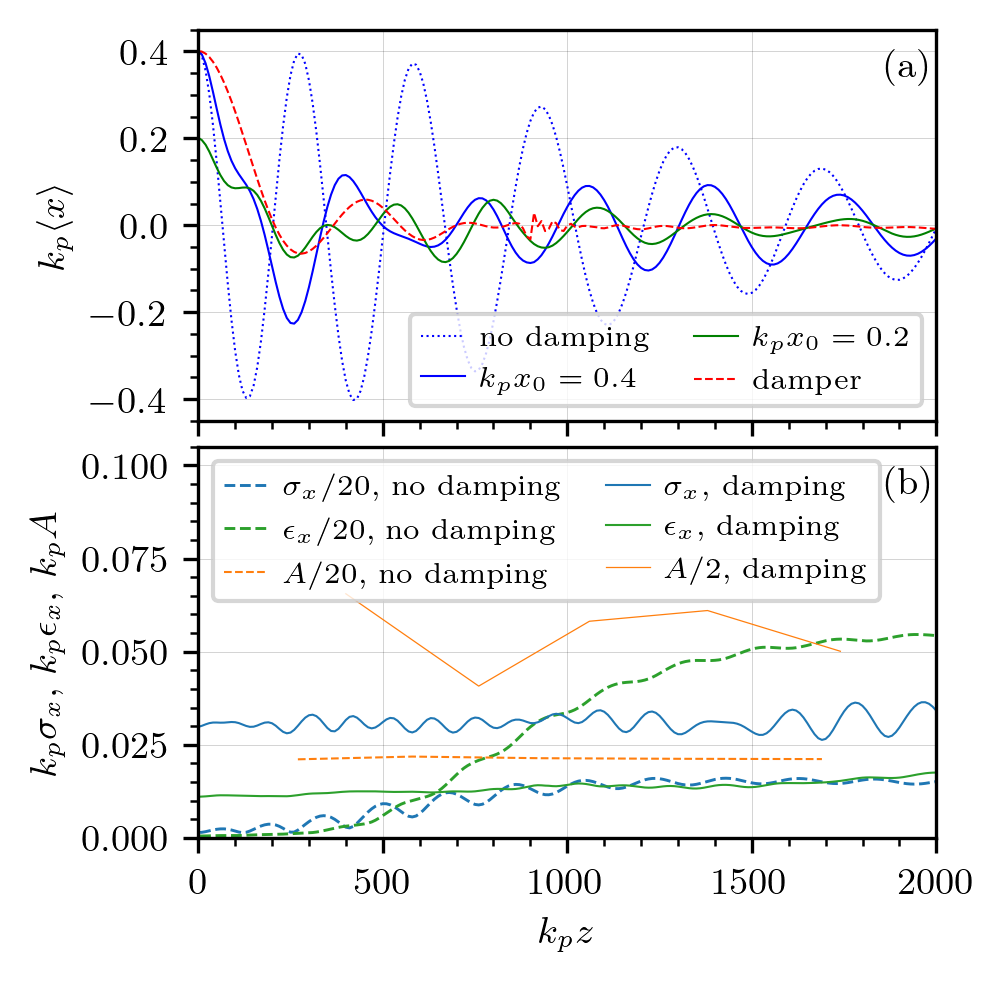

In [68]:
fig = plt.figure(figsize=(83*mm, 80*mm), dpi=300)

# Plot average x positions.
plt.subplot(211)

r = np.load('./res-no-damping-0.4.npz')
plt.plot(r['t'], r['x'], lw = 0.5, c = 'b', ls = ':', label='no damping')

r = np.load('./res-damping-0.4.npz')
plt.plot(r['t'], r['x'], lw = 0.5, c = 'b', label=r'$k_p x_0 = 0.4$')

r = np.load('./res-damping-0.2.npz')
plt.plot(r['t'], r['x'], lw = 0.5, c = 'g', label=r'$k_p x_0 = 0.2$')

path = './diagnostics/damping-0.4/'
beam = np.load(path + 'beam_00005.00.npz')
idmin = min(beam['id'][beam['xi'] < -13])
files = sorted(glob.glob(path + '/beam*npz'))
ts, xs = [], []
for file in files:
    beam = np.load(file)
    time = float(file[-12:-4])
    x = beam['x'][beam['id']<idmin]
    xav = np.mean(x)
    ts.append(time)
    xs.append(xav)
plt.plot(ts, xs, lw = 0.5, c = 'r', ls = '--', label='damper')

plt.ylabel(r'$k_p \langle x \rangle$')
plt.xlim(0,2000)
plt.ylim(-0.45,0.45)
plt.minorticks_on()
plt.grid(which='major', alpha=0.2, c='k', lw=0.2)
plt.legend(ncol=2, loc=4, columnspacing=1.5, handletextpad=0.5, 
           handlelength=1.5)
ax=plt.gca()
ax.axes.xaxis.set_ticklabels([])
plt.text(0.93, 0.88, '(a)', fontsize=9, transform=ax.transAxes)

# Plot witness macro parameters.
plt.subplot(212)

r = np.load('./res-no-damping-0.4.npz')
plt.plot(r['t'], r['sx']/20, lw = 0.7, c = 'tab:blue', ls = '--', 
         label=r'$\sigma_x/20$, no damping')
plt.plot(r['t'], r['emx']/20, lw = 0.7, c = 'tab:green', ls = '--', 
         label=r'$\epsilon_x/20$, no damping')
ex = argrelextrema(r['x'], np.greater)
A = (np.sqrt(r['x'][ex[0]]**2 + r['sx'][ex[0]]**2)
     * (r['uz'][ex[0]]/r['uz'][0])**(1/4) / 20)
plt.plot(r['t'][ex[0]], A, 
         lw = 0.5, c = 'tab:orange', ls='--', label=r'$A/20$, no damping')

r = np.load('./res-damping-0.4.npz')
plt.plot(r['t'], r['sx'], lw = 0.5, c = 'tab:blue', 
         label=r'$\sigma_x$, damping')
plt.plot(r['t'], r['emx'], lw = 0.5, c = 'tab:green', 
         label=r'$\epsilon_x$, damping')
ex = argrelextrema(r['x'], np.greater)
A = (np.sqrt(r['x'][ex[0]]**2 + r['sx'][ex[0]]**2)
     * (r['uz'][ex[0]]/r['uz'][0])**(1/4) / 2)
plt.plot(r['t'][ex[0]], A,  
         lw = 0.3, c = 'tab:orange', ls='-', label=r'$A/2$, damping')

plt.ylabel(r'$k_p \sigma_x$, $k_p \epsilon_x$, $k_p A$')
plt.xlim(0,2000)
plt.ylim(0,0.105)
plt.minorticks_on()
plt.grid(which='major', alpha=0.2, c='k', lw=0.2)
plt.legend(ncol=2, loc=2, columnspacing=1.5,
           handletextpad=0.5, handlelength=1.5)
plt.xlabel(r'$k_p z$')
ax=plt.gca()
plt.text(0.93, 0.88, '(b)', fontsize=9, transform=ax.transAxes)

plt.tight_layout(pad=0.3)
plt.savefig('./beam-parameters.png', format='png', dpi=300, bbox_inches='tight')


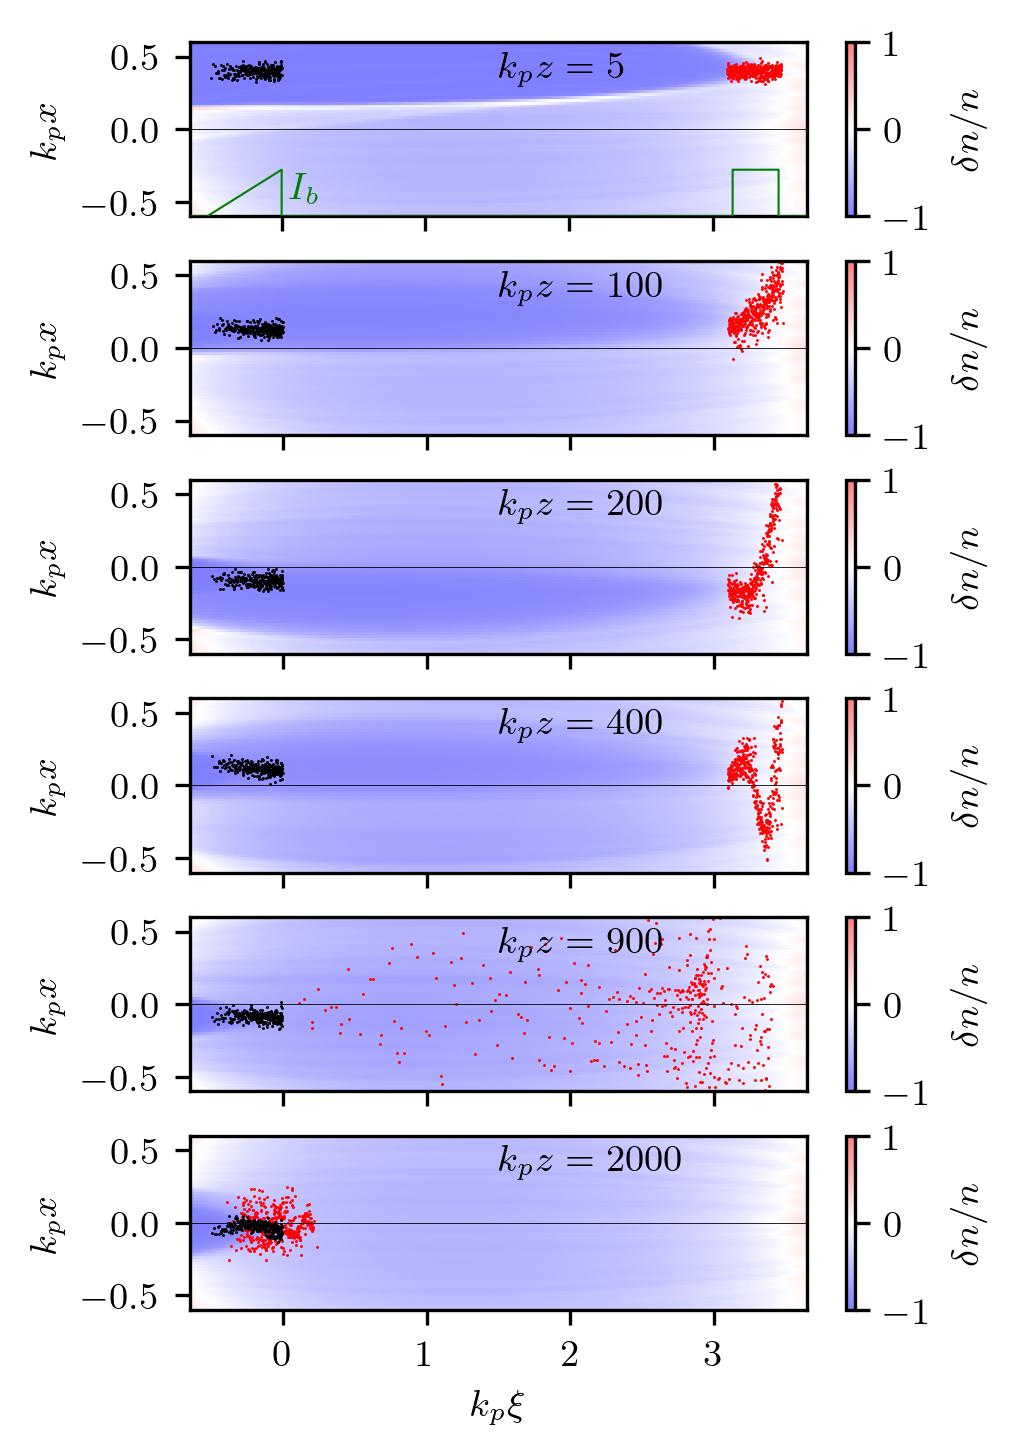

In [64]:
def plot_fragment(path, time, each=10, zero=-13.66):
    cmap = np.load(path + f"slice_{time:08.2f}.npz")
    ro = -(cmap['ne'].T)-1
    xis = cmap['xi']
    xs = cmap['x']
    plt.pcolormesh(xis - zero, xs, ro, cmap='bwr', vmin=-1, vmax=1, 
                   rasterized=True, alpha=0.5)
    plt.colorbar(label=r'$\delta n / n$', orientation="vertical")
    beam = np.load(path + f"beam_{time:08.2f}.npz")
    plt.scatter(beam['xi'][beam['id']<idmin][::each] - zero, 
                beam['x'][beam['id']<idmin][::each], lw = 0, s = 0.5, c = 'r')
    plt.scatter(beam['xi'][beam['id']>=idmin][::each] - zero, 
                beam['x'][beam['id']>=idmin][::each], lw = 0, s = 0.5, c = 'k')
    plt.axhline(y=0, lw = 0.2, color = 'k')
    plt.ylabel(r'$k_p x$')
    plt.ylim(-0.6, 0.6)
    ax=plt.gca()
    plt.text(0.5, 0.8, f'$k_p z={time:.0f}$', transform=ax.transAxes, c='k')
    

path = "./diagnostics/damping-0.4/"

beam = np.load(path + 'beam_00005.00.npz')
idmin = min(beam['id'][beam['xi'] < -13])

fig = plt.figure(figsize=(83*mm, 120*mm), dpi=300)

plt.subplot(611)
plot_fragment(path, 5)
ax=plt.gca()
ax.axes.xaxis.set_ticklabels([])
ax2 = ax.twinx()
Ib = np.array([[-0.64, 0], [-0.52, 0], [0, 0.0268], [0, 0], [3.14, 0], 
               [3.14, 0.0268], [3.46, 0.0268], [3.46, 0], [3.66, 0]]).T
plt.plot(Ib[0], Ib[1], lw=0.5, c='g')
plt.xlim(-0.64, 3.66)
plt.ylim(0, 0.1)
ax2.axis('off')
plt.text(0.16, 0.1, r'$I_b$', c='g', transform=ax2.transAxes)

plt.subplot(612)
plot_fragment(path, 100)
ax=plt.gca()
ax.axes.xaxis.set_ticklabels([])

plt.subplot(613)
plot_fragment(path, 200)
ax=plt.gca()
ax.axes.xaxis.set_ticklabels([])

plt.subplot(614)
plot_fragment(path, 400)
ax=plt.gca()
ax.axes.xaxis.set_ticklabels([])

plt.subplot(615)
plot_fragment(path, 900)
ax=plt.gca()
ax.axes.xaxis.set_ticklabels([])

plt.subplot(616)
plot_fragment(path, 2000)
plt.xlabel(r'$k_p \xi$')

plt.tight_layout(pad=0.3)
plt.savefig('./damping.png', format='png', dpi=300, bbox_inches='tight')